# Satellite Terrain Classification with a Custom CNN

End-to-end deep-learning pipeline that classifies 64x64 Sentinel-2 satellite tiles into ten land-use / land-cover categories using a VGG-style convolutional neural network built and trained **from scratch** in PyTorch.

The notebook walks through the full workflow — data handling and pre-processing, exploratory data analysis, model design, training with early stopping, and evaluation (accuracy, macro-F1 and a confusion matrix). The final model reaches **97.35% validation accuracy** (macro-F1 0.9735, Cohen's kappa 0.9706).

In [1]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import os
import copy
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cpu


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Run everything from the repository root (the folder that contains data/,
# models/ and outputs/). The notebook lives in notebooks/, so step up one
# level when it is launched from there.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(f"Working directory: {os.getcwd()}")

Working directory: /home/dimi/Courses/2. Semester/Python_2/UE/satelite_image_classification


In [5]:
# Create output folders for trained weights, plots and the submission file.
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

## Data Handling and Pre-Processing

In [6]:
def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    """Scan a folder with one sub-folder per class and build:
      * a DataFrame with the folder, file name and a numeric label per image,
      * a dict mapping every class name to its numeric label.
    """
    # Sorted class names -> deterministic, reproducible label assignment.
    class_names = sorted(
        d for d in os.listdir(data_folder)
        if os.path.isdir(os.path.join(data_folder, d))
    )
    label_dict = {name: idx for idx, name in enumerate(class_names)}

    rows = []
    for name in class_names:
        folder = os.path.join(data_folder, name)
        for file_name in sorted(os.listdir(folder)):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({
                    "folder": folder,
                    "file_name": file_name,
                    "label": label_dict[name],
                })
    df = pd.DataFrame(rows, columns=["folder", "file_name", "label"])
    return df, label_dict


def preprocess_test(data_folder: str) -> pd.DataFrame:
    """Build a DataFrame with folder + file_name for the (flat) test directory."""
    rows = [
        {"folder": data_folder, "file_name": f}
        for f in sorted(os.listdir(data_folder))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    return pd.DataFrame(rows, columns=["folder", "file_name"])

In [7]:
# Build the DataFrame and the label dictionary from the training data folder.
df, label_dict = preprocess("data/train")
# Inverse mapping (numeric label -> class name) used throughout the notebook.
idx_to_class = {v: k for k, v in label_dict.items()}

print(f"Length of dataset: {len(df)}")  # Should be 10000
print(label_dict)
df.head(10)

Length of dataset: 10000
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


,folder,file_name,label
0,data/train/AnnualCrop,AnnualCrop_1.jpg,0
1,data/train/AnnualCrop,AnnualCrop_100.jpg,0
2,data/train/AnnualCrop,AnnualCrop_1004.jpg,0
3,data/train/AnnualCrop,AnnualCrop_1005.jpg,0
4,data/train/AnnualCrop,AnnualCrop_101.jpg,0
5,data/train/AnnualCrop,AnnualCrop_1014.jpg,0
6,data/train/AnnualCrop,AnnualCrop_1018.jpg,0
7,data/train/AnnualCrop,AnnualCrop_1019.jpg,0
8,data/train/AnnualCrop,AnnualCrop_1024.jpg,0
9,data/train/AnnualCrop,AnnualCrop_1025.jpg,0


In [8]:
# Stratified, reproducible 80/20 train/validation split.
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
# Verify the split stayed balanced across classes.
print(train_df["label"].value_counts().sort_index().to_dict())

Training samples:   8000
Validation samples: 2000
{0: 800, 1: 800, 2: 800, 3: 800, 4: 800, 5: 800, 6: 800, 7: 800, 8: 800, 9: 800}


## Exploratory Data Analysis (EDA)

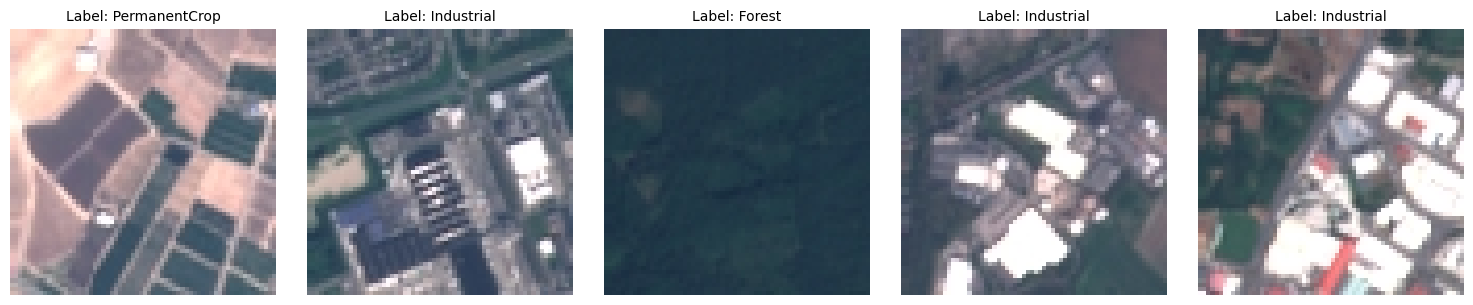

In [9]:
def _load_image(row) -> Image.Image:
    """Helper: open an image referenced by a DataFrame row as an RGB PIL image."""
    return Image.open(os.path.join(row.folder, row.file_name)).convert("RGB")


def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    """Randomly select `num_samples` images and display them side by side.
    The figure is shown and also saved to outputs/plots/random_samples.png."""
    sample = df.sample(num_samples, random_state=SEED)
    fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3))
    if num_samples == 1:
        axes = [axes]
    for ax, row in zip(axes, sample.itertuples(index=False)):
        ax.imshow(_load_image(row))
        ax.set_title(f"Label: {idx_to_class[row.label]}", fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig("outputs/plots/random_samples.png", dpi=120, bbox_inches="tight")
    plt.show()


show_samples(df, num_samples=5)

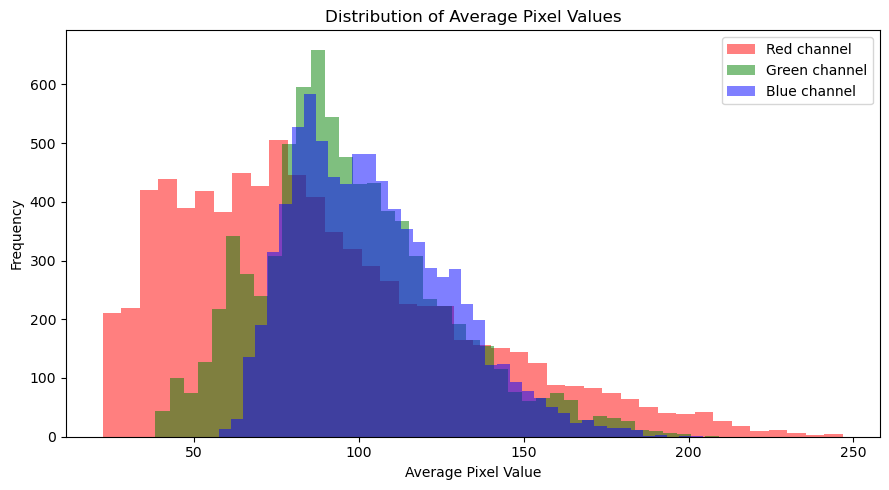

In [10]:
def average_pixel_plot(df: pd.DataFrame) -> None:
    """Plot the distribution of the per-image average pixel value for each of
    the three colour channels. Shown and saved to
    outputs/plots/average_pixel_distribution.png."""
    # Average pixel value per image and per channel (R, G, B).
    means = np.array([
        np.asarray(_load_image(row)).reshape(-1, 3).mean(axis=0)
        for row in df.itertuples(index=False)
    ])
    fig, ax = plt.subplots(figsize=(9, 5))
    for c, color in enumerate(["red", "green", "blue"]):
        ax.hist(means[:, c], bins=40, color=color, alpha=0.5,
                label=f"{color.capitalize()} channel")
    ax.set_title("Distribution of Average Pixel Values")
    ax.set_xlabel("Average Pixel Value")
    ax.set_ylabel("Frequency")
    ax.legend()
    fig.tight_layout()
    fig.savefig("outputs/plots/average_pixel_distribution.png",
                dpi=120, bbox_inches="tight")
    plt.show()


# EDA is performed on the training set.
average_pixel_plot(train_df)

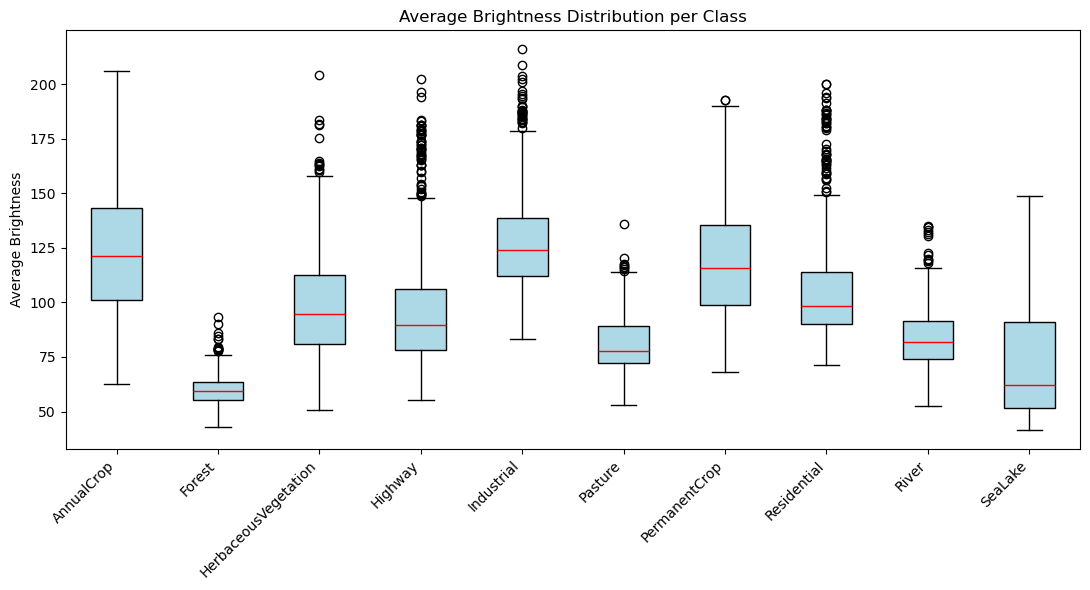

In [11]:
def average_brightness_per_class(df: pd.DataFrame) -> None:
    """Boxplot of the average brightness (mean over all three channels) for
    each class. Shown and saved to outputs/plots/average_brightness.png."""
    brightness = np.array([
        np.asarray(_load_image(row)).mean()
        for row in df.itertuples(index=False)
    ])
    labels_sorted = sorted(df["label"].unique())
    classes = [idx_to_class[i] for i in labels_sorted]
    data = [brightness[df["label"].values == i] for i in labels_sorted]

    fig, ax = plt.subplots(figsize=(11, 6))
    bp = ax.boxplot(data, labels=classes, patch_artist=True,
                    medianprops=dict(color="red"))
    for box in bp["boxes"]:
        box.set_facecolor("lightblue")
    ax.set_title("Average Brightness Distribution per Class")
    ax.set_ylabel("Average Brightness")
    ax.set_xticklabels(classes, rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig("outputs/plots/average_brightness.png",
                dpi=120, bbox_inches="tight")
    plt.show()


average_brightness_per_class(train_df)

## CNN Implementation and Training

### Dataset class

In [12]:
# Per-channel normalization statistics, computed once from the TRAINING split
# (mean/std of pixel values scaled to [0, 1]). Hard-coded here so that the exact
# same values are used for training, evaluation and the Shiny app.
MEAN = [0.3513, 0.3845, 0.4071]
STD = [0.2025, 0.1376, 0.1168]

# Training transforms include light, label-preserving augmentation. Satellite
# images have no canonical orientation, so flips/rotations are safe.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Validation/test transforms only convert to tensor and normalize (no augmentation).
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class EuroSATDataset(Dataset):
    """Dataset backed by a preprocess() DataFrame. The images are small and few,
    so they are decoded once and cached in RAM to keep CPU epochs fast."""

    def __init__(self, df: pd.DataFrame, transform=None, has_labels: bool = True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels
        self.images = [
            Image.open(os.path.join(r.folder, r.file_name)).convert("RGB").copy()
            for r in self.df.itertuples(index=False)
        ]
        if has_labels:
            self.labels = self.df["label"].to_numpy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        if self.has_labels:
            return img, int(self.labels[idx])
        return img

### Data Loaders

In [13]:
BATCH_SIZE = 64

train_dataset = EuroSATDataset(train_df, train_transform)
val_dataset = EuroSATDataset(val_df, eval_transform)

# Seeded generator so that shuffling is reproducible.
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=g)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False,
                        num_workers=0)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 125 | Val batches: 8


### Model Architecture

In [14]:
class SatelliteCNN(nn.Module):
    """A VGG-style CNN built from scratch (no pretrained weights / transfer
    learning) for 64x64 RGB images -> 10 classes. Each block is two 3x3
    convolutions with batch normalization and ReLU, followed by max pooling."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),     # 64 -> 32
            block(32, 64),    # 32 -> 16
            block(64, 128),   # 16 -> 8
            block(128, 256),  # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SatelliteCNN(num_classes=len(label_dict)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

SatelliteCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(i

### Training Loop

In [15]:
WEIGHTS_PATH = "models/best_model.pt"
HISTORY_PATH = "outputs/history.json"
EPOCHS = 50
PATIENCE = 12          # early-stopping patience (epochs without val-acc improvement)
LEARNING_RATE = 1e-3


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Return (average loss, accuracy) of `model` over `loader`."""
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total


def train_model(model):
    """Standard training loop with Adam, cosine LR scheduling, tracking of
    train/val loss & accuracy, best-model checkpointing and early stopping."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                                 weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, epochs_no_improve = 0.0, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()          # backward pass
            optimizer.step()         # optimizer step
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        scheduler.step()

        tr_loss, tr_acc = loss_sum / total, correct / total
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # Save the best model (highest validation accuracy).
        if va_acc > best_acc:
            best_acc = va_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), WEIGHTS_PATH)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
              f"best {best_acc:.4f}")

        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)
    return history, best_acc


# Train if no checkpoint exists yet; otherwise reuse the saved best model. This
# keeps re-runs fast while remaining fully reproducible when training from scratch.
if os.path.exists(WEIGHTS_PATH) and os.path.exists(HISTORY_PATH):
    print("Found existing checkpoint -> loading weights, skipping training.")
    with open(HISTORY_PATH) as f:
        history = json.load(f)
else:
    print("No checkpoint found -> training from scratch...")
    history, best_acc = train_model(model)

# Load the best weights into the model for evaluation.
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
_ = model.eval()
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")

Found existing checkpoint -> loading weights, skipping training.
Best validation accuracy: 0.9735


## Model Evaluation

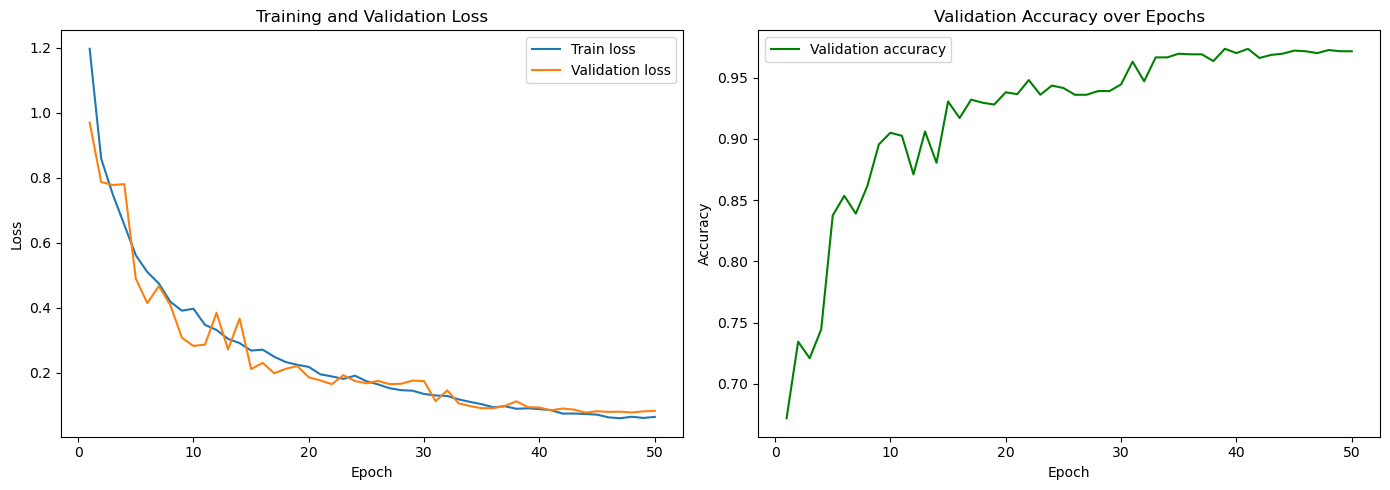

In [16]:
def plot_training_curves(history) -> None:
    """Loss curves (train + val) and validation accuracy, side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train loss")
    ax1.plot(epochs, history["val_loss"], label="Validation loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Training and Validation Loss"); ax1.legend()

    ax2.plot(epochs, history["val_acc"], color="green",
             label="Validation accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title("Validation Accuracy over Epochs"); ax2.legend()

    fig.tight_layout()
    fig.savefig("outputs/plots/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_training_curves(history)

Validation accuracy: 0.9735


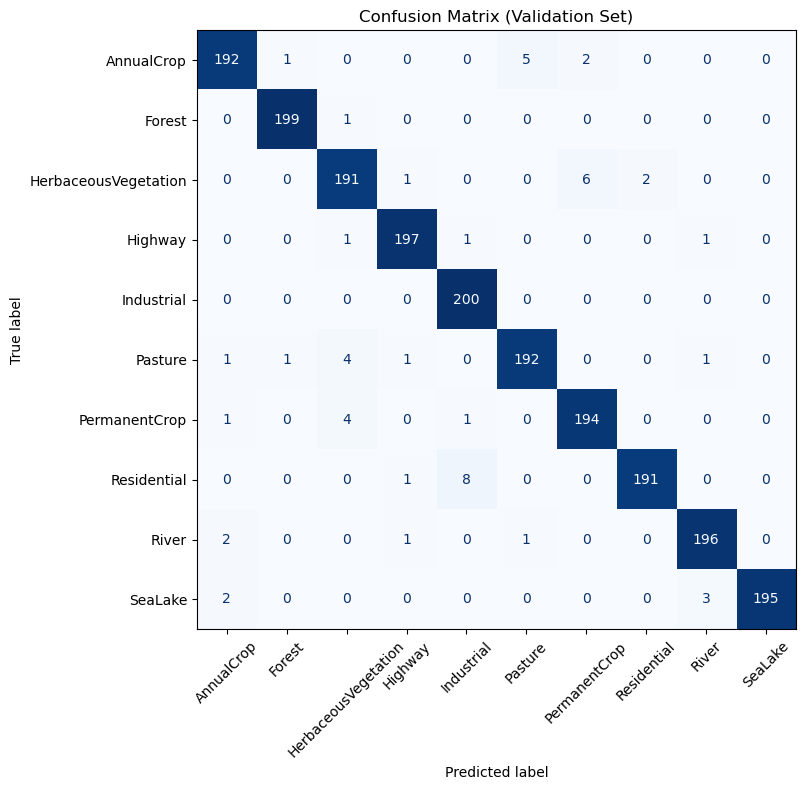

In [17]:
@torch.no_grad()
def predict_loader(model, loader, with_labels=True):
    """Return model predictions (and labels, if available) over a loader."""
    model.eval()
    preds, labels = [], []
    for batch in loader:
        x = batch[0] if with_labels else batch
        out = model(x.to(device))
        preds.append(out.argmax(1).cpu().numpy())
        if with_labels:
            labels.append(batch[1].numpy())
    preds = np.concatenate(preds)
    labels = np.concatenate(labels) if with_labels else None
    return preds, labels


def plot_confusion_matrix(y_true, y_pred) -> None:
    """Confusion matrix of the model on the validation set."""
    cm = confusion_matrix(y_true, y_pred)
    names = [idx_to_class[i] for i in range(len(idx_to_class))]
    disp = ConfusionMatrixDisplay(cm, display_labels=names)
    fig, ax = plt.subplots(figsize=(9, 8))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title("Confusion Matrix (Validation Set)")
    fig.tight_layout()
    fig.savefig("outputs/plots/confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()


# Predictions on the validation set.
val_pred, val_true = predict_loader(model, val_loader, with_labels=True)
val_accuracy = (val_pred == val_true).mean()
print(f"Validation accuracy: {val_accuracy:.4f}")
plot_confusion_matrix(val_true, val_pred)

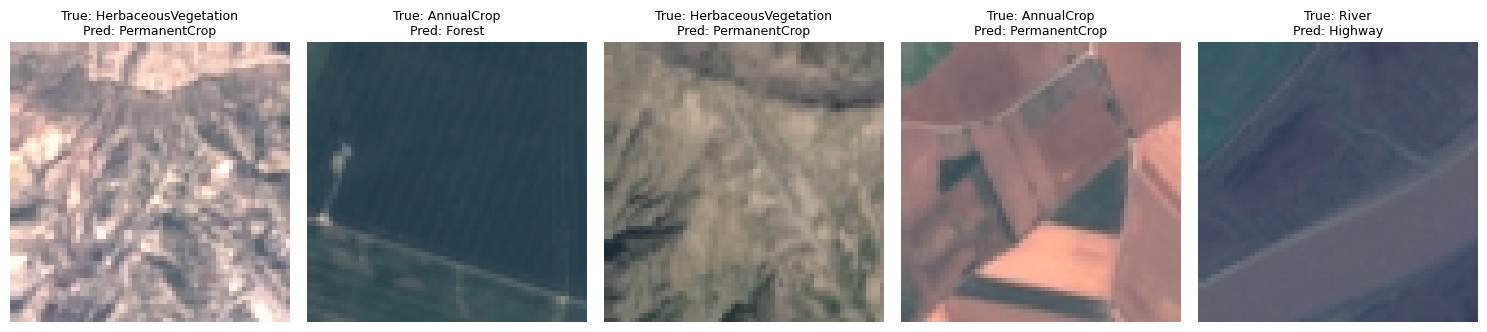

In [18]:
def plot_misclassified_samples(val_df, y_true, y_pred, num_samples: int = 5) -> None:
    """Show `num_samples` misclassified validation images with their true and
    predicted labels (like show_samples, but with the predicted label added)."""
    misclassified = np.where(y_true != y_pred)[0]
    rng = np.random.default_rng(SEED)
    pick = rng.choice(misclassified, size=min(num_samples, len(misclassified)),
                      replace=False)

    fig, axes = plt.subplots(1, len(pick), figsize=(3 * len(pick), 3.2))
    if len(pick) == 1:
        axes = [axes]
    for ax, i in zip(axes, pick):
        row = val_df.iloc[i]
        ax.imshow(_load_image(row))
        ax.set_title(f"True: {idx_to_class[y_true[i]]}\n"
                     f"Pred: {idx_to_class[y_pred[i]]}", fontsize=9)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig("outputs/plots/misclassified_samples.png",
                dpi=120, bbox_inches="tight")
    plt.show()


plot_misclassified_samples(val_df, val_true, val_pred, num_samples=5)

### Test Set

In [19]:
# The test directory is flat (no class sub-folders), just numbered image files.
test_df = preprocess_test("data/test")
print(f"Test images: {len(test_df)}")
test_df.head()

Test images: 1980


,folder,file_name
0,data/test,1001.jpg
1,data/test,1002.jpg
2,data/test,1008.jpg
3,data/test,101.jpg
4,data/test,1034.jpg


In [20]:
# Dataset + DataLoader for the test set (no labels, evaluation transforms only).
test_dataset = EuroSATDataset(test_df, eval_transform, has_labels=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
print(f"Test batches: {len(test_loader)}")

Test batches: 8


In [21]:
# Predict the class for every test image.
test_pred, _ = predict_loader(model, test_loader, with_labels=False)
print(f"Predicted {len(test_pred)} test images.")
# Quick look at the predicted class distribution.
pd.Series([idx_to_class[p] for p in test_pred]).value_counts()

Predicted 1980 test images.


HerbaceousVegetation    310
PermanentCrop           206
SeaLake                 193
Highway                 188
River                   186
Pasture                 184
Forest                  182
Industrial              181
Residential             178
AnnualCrop              172
Name: count, dtype: int64

In [22]:
# Build the submission file for the challenge server:
#   file name, predicted class name  (as text, no header row).
submission = pd.DataFrame({
    "file_name": test_df["file_name"],
    "label": [idx_to_class[p] for p in test_pred],
})
submission.to_csv("outputs/submission.csv", index=False, header=False)
print("Wrote outputs/submission.csv")
print(submission.head(7).to_string(index=False, header=False))

Wrote outputs/submission.csv
1001.jpg HerbaceousVegetation
1002.jpg          Residential
1008.jpg        PermanentCrop
 101.jpg              Highway
1034.jpg HerbaceousVegetation
1042.jpg           AnnualCrop
1046.jpg        PermanentCrop
